In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q gdown

In [3]:
!gdown --id 14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ --output animals10.zip

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ
From (redirected): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ&confirm=t&uuid=988f57da-ce24-4361-979a-8e6ee019de91
To: /content/animals10.zip
100% 614M/614M [00:11<00:00, 53.7MB/s]


In [4]:
!unzip -q animals10.zip -d ./animals10

In [5]:
# import shutil
# import os

# root_dir = '/content/animals10/'

# for item in os.listdir(root_dir):
#     item_path = os.path.join(root_dir, item)

#     try:
#         if os.path.isfile(item_path) or os.path.islink(item_path):
#             os.unlink(item_path)
#         elif os.path.isdir(item_path):
#             shutil.rmtree(item_path)
#     except Exception as e:
#         print(f"Помилка при видаленні {item_path}: {e}")


In [6]:
data_dir = './animals10/raw-img'

translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

In [7]:
import os

for italian, english in translate.items():
    src = os.path.join(data_dir, italian)
    dst = os.path.join(data_dir, english)

    if os.path.exists(src):
        os.rename(src, dst)

In [8]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


data = datasets.ImageFolder(data_dir, transform=transform)

In [9]:
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

labels = np.array(data.targets)

train_val_idx, test_idx = train_test_split(
    np.arange(len(data)), test_size=0.2, random_state=42, shuffle=True, stratify=labels
)

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=42, shuffle=True, stratify=labels[train_val_idx]
)

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)
test_data = Subset(data, test_idx)

In [10]:
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Train size: 15707
Validation size: 5236
Test size: 5236


In [11]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 2

train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)

val_loader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [13]:
train_loader.dataset.transform = train_transform
val_loader.dataset.transform = val_test_transform
test_loader.dataset.transform = val_test_transform

In [38]:
import torch.nn as nn
from torchvision import models
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [57]:
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [58]:
for param in model.parameters():
    param.requires_grad = False

In [59]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [60]:
model = model.to(device)

In [61]:
for param in model.fc.parameters():
    param.requires_grad = True

In [62]:
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
criterion = nn.CrossEntropyLoss()

In [63]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [64]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

In [65]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test_evaluate(model, loader, criterion, device):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * inputs.size(0)
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    avg_loss = total_loss / total

    return avg_loss, acc, f1

In [66]:
def unfreeze_layers(model, num_layers_to_unfreeze):
    children = list(model.children())[:-2]
    layers = [child for child in children if isinstance(child, nn.Sequential)]

    total_layers = len(layers)
    layers_to_unfreeze = layers[-num_layers_to_unfreeze:]

    for layer in layers_to_unfreeze:
        for param in layer.parameters():
            param.requires_grad = True

In [67]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

In [68]:
for epoch in range(11):
    if epoch in [3, 4, 5]:
        unfreeze_layers(model, epoch - 2)

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch+1} — "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

Epoch 1 — Train Loss: 0.2619, Acc: 0.9333 | Val Loss: 0.1212, Acc: 0.9650, F1: 0.9651
Epoch 2 — Train Loss: 0.1418, Acc: 0.9569 | Val Loss: 0.1691, Acc: 0.9450, F1: 0.9465
Epoch 3 — Train Loss: 0.1050, Acc: 0.9694 | Val Loss: 0.0995, Acc: 0.9689, F1: 0.9688
Epoch 4 — Train Loss: 0.1016, Acc: 0.9696 | Val Loss: 0.0999, Acc: 0.9687, F1: 0.9687
Epoch 5 — Train Loss: 0.0954, Acc: 0.9714 | Val Loss: 0.0988, Acc: 0.9696, F1: 0.9696
Epoch 6 — Train Loss: 0.0971, Acc: 0.9703 | Val Loss: 0.0992, Acc: 0.9675, F1: 0.9676
Epoch 7 — Train Loss: 0.0994, Acc: 0.9712 | Val Loss: 0.0978, Acc: 0.9693, F1: 0.9693
Epoch 8 — Train Loss: 0.0994, Acc: 0.9695 | Val Loss: 0.0994, Acc: 0.9677, F1: 0.9677
Epoch 9 — Train Loss: 0.0994, Acc: 0.9700 | Val Loss: 0.1004, Acc: 0.9683, F1: 0.9683
Epoch 10 — Train Loss: 0.0992, Acc: 0.9703 | Val Loss: 0.0987, Acc: 0.9702, F1: 0.9702
Epoch 11 — Train Loss: 0.1000, Acc: 0.9701 | Val Loss: 0.0984, Acc: 0.9694, F1: 0.9695


In [69]:
torch.save(model.state_dict(), 'model4_1.pth')

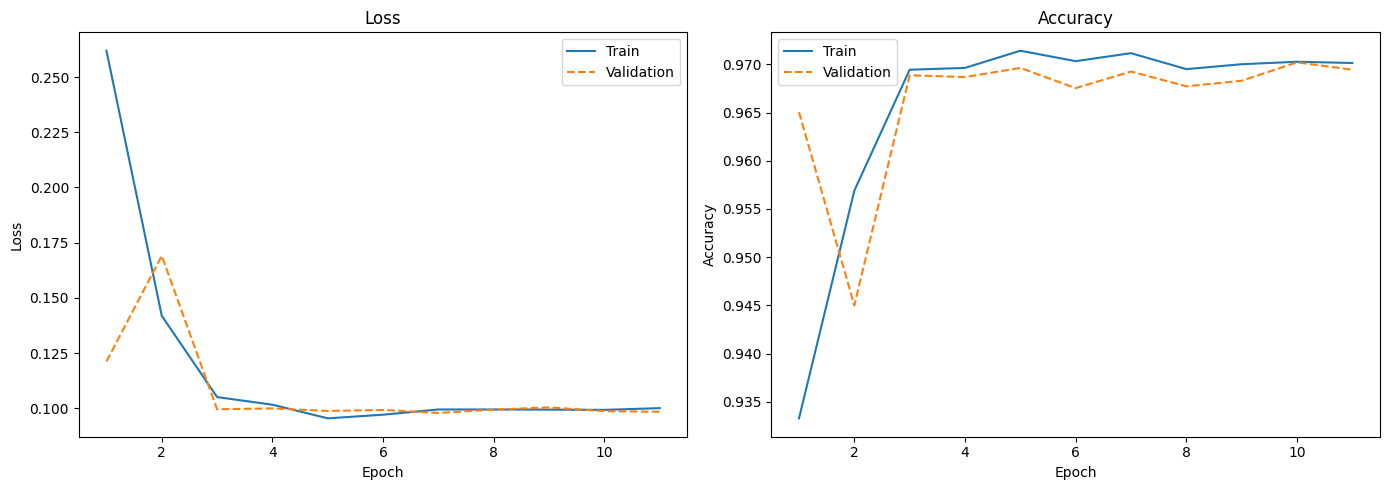

In [81]:
epoch_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, train_losses, label='Train')
plt.plot(epoch_range, val_losses, label='Validation', linestyle='--')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_range, train_accuracies, label='Train')
plt.plot(epoch_range, val_accuracies, label='Validation', linestyle='--')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [73]:
import random
import torchvision.transforms.functional as F

model.eval()
all_preds = []
all_labels = []
wrong_samples = []

In [74]:
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        wrong_indices = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in wrong_indices:
            wrong_samples.append((inputs[idx].cpu(), preds[idx].item(), labels[idx].item()))

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

In [75]:
print(f"Validation Accuracy: {acc:.4f}")
print(f"Validation F1-score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Validation Accuracy: 0.9694
Validation F1-score: 0.9695

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       423
           1       0.96      0.98      0.97       333
           2       0.99      0.98      0.98       620
           3       0.93      0.94      0.93       373
           4       0.97      0.97      0.97       973
           5       0.98      0.98      0.98       289
           6       0.95      0.94      0.95       525
           7       0.94      0.95      0.94       364
           8       0.99      0.99      0.99       964
           9       0.98      0.98      0.98       372

    accuracy                           0.97      5236
   macro avg       0.97      0.97      0.97      5236
weighted avg       0.97      0.97      0.97      5236



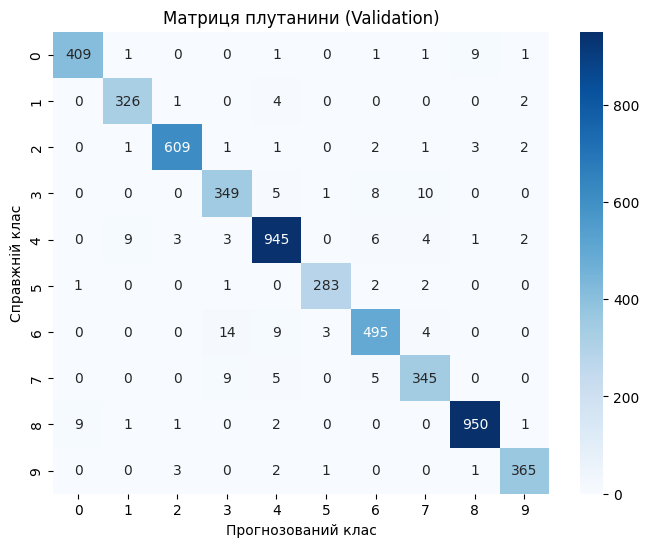

In [76]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матриця плутанини (Validation)')
plt.xlabel('Прогнозований клас')
plt.ylabel('Справжній клас')
plt.show()

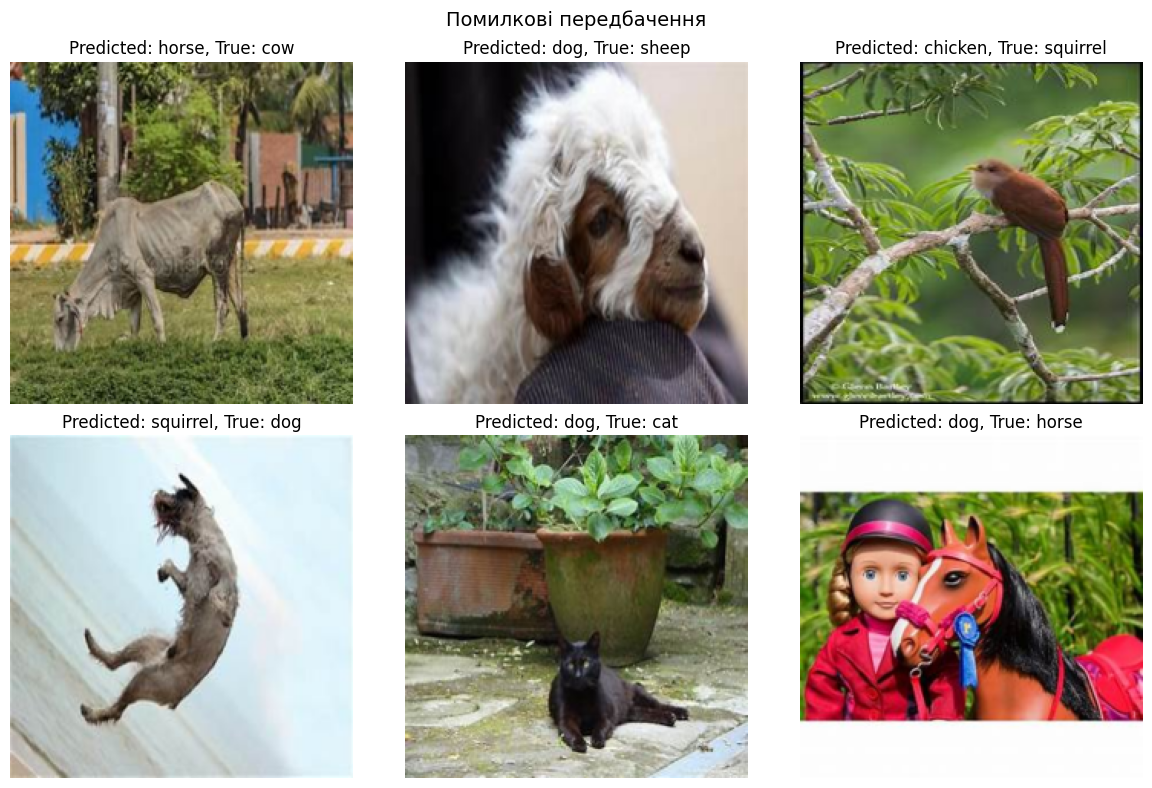

In [79]:
idx_to_class = {v: k for k, v in data.class_to_idx.items()}

if wrong_samples:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for i, (img_tensor, pred, true) in enumerate(random.sample(wrong_samples, min(6, len(wrong_samples)))):
        img = F.to_pil_image(img_tensor)
        axes[i].imshow(img)
        axes[i].set_title(f'Predicted: {idx_to_class[pred]}, True: {idx_to_class[true]}')
        axes[i].axis('off')

    plt.suptitle("Помилкові передбачення", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Усі передбачення правильні — немає помилкових зразків.")
